<a href="https://colab.research.google.com/github/NourahAziz333/Astrogaurd/blob/main/Astrogaurd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AstroGuard Project**
# **Phase 2: Data Preparation**

**1. Connect to Google Drive**


First, we need to mount Google Drive.
This will allow our Colab notebook to access the files stored there.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**2. Load the Dataset**

Next, we'll load the asteroid dataset using pandas.

In [ ]:
import pandas as pd

# supposed dataset from google drive
file_path = '/content/drive/My Drive/Cs465project/dataset.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("File not found. Please double-check the 'file_path' variable and make sure it's correct.")

/tmp/ipython-input-3871989724.py:7: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dataset loaded successfully!


**3. Initial Data Inspection**

Now that the data is loaded, we'll inspect it to understand its structure, check for missing values, and review data types.

In [ ]:
# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Get a concise summary of the dataframe
print("\nDataFrame Info:")
df.info()

# Check for missing values in each column
print("\nMissing values per column:")
print(df.isnull().sum())

First 5 rows of the dataset:


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.610000e-09,6.170000e-08,6.620000e-08,7.820000e-09,1.110000e-11,1.200000e-12,3.780000e-08,9.420000e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.470000e-06,6.270000e-06,9.130000e-06,8.860000e-06,4.960000e-09,4.650000e-10,4.080000e-05,3.680000e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.220000e-06,1.660000e-05,1.770000e-05,8.110000e-06,4.360000e-09,4.410000e-10,3.530000e-05,3.110000e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170000e-07,3.880000e-07,1.790000e-07,1.210000e-06,1.650000e-09,2.610000e-10,4.100000e-06,1.270000e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740000e-06,2.890000e-05,2.980000e-05,8.300000e-06,4.730000e-09,5.520000e-10,3.470000e-05,3.490000e-06,MBA,0.52191



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  int64  
 16  equinox         958524 non-null  object

**Supposed Observations:**

The dataset contains the **key features** needed for the **project:**
- absolute_magnitude
- est_diameter_max
- relative_velocity
- miss_distance
- And the **target hazardous**

The hazardous column is a **boolean**, which needs to be **converted** to a number (1/0) for machine learning.

The **initial** check shows no **missing values**, which simplifies our **cleaning** process.

Columns like **id, name,** and **orbiting_bod**y are **not relevant** for prediction and can be **removed**.

**4. Data Cleaning and Preprocessing**

Based on our observations, we will now clean the data by selecting the relevant features and encoding the target variable.

In [ ]:
#1. Handle Missing Values

#Features with many missing data that are not critical will be dropped.

columns_to_drop = ['name', 'prefix', 'albedo', 'diameter_sigma']
df_cleaned = df.drop(columns=columns_to_drop)

# For the critical 'diameter' feature, we will remove rows where it's missing.
# We will also remove rows where other key features are missing to ensure a complete dataset.
key_features = ['H', 'diameter', 'pha', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'per']
df_cleaned = df_cleaned.dropna(subset=key_features)


#2. Encode the Target Variable

# The 'pha' (Potentially Hazardous Asteroid) column will be our target.
# 'Y' (Yes) will be encoded as 1, and 'N' (No) will be encoded as 0.
df_cleaned['hazardous'] = (df_cleaned['pha'] == 'Y').astype(int)


#3. Select Final Features

# Select the final set of features for the model, including our new 'hazardous' column.

final_features_to_keep = [
    'H',                # Absolute Magnitude
    'diameter',
    'e',                # Eccentricity
    'a',                # Semi-major axis
    'q',                # Perihelion distance
    'i',                # Inclination
    'om',               # Longitude of the ascending node
    'w',                # Argument of perihelion
    'ma',               # Mean anomaly
    'ad',               # Aphelion distance
    'n',                # Mean motion
    'tp',               # Time of perihelion passage
    'per',              # Orbital period
    'hazardous'         # Our new target variable
]
df_final_cleaned = df_cleaned[final_features_to_keep]


#4. Verify the Cleaned Data

print("Cleaned DataFrame Info:")
df_final_cleaned.info()

print("\nFirst 5 rows of the final cleaned dataset:")
display(df_final_cleaned.head())

print("\nValue counts for the 'hazardous' column:")
print(df_final_cleaned['hazardous'].value_counts())

Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 132045 entries, 0 to 909489
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   H          132045 non-null  float64
 1   diameter   132045 non-null  float64
 2   e          132045 non-null  float64
 3   a          132045 non-null  float64
 4   q          132045 non-null  float64
 5   i          132045 non-null  float64
 6   om         132045 non-null  float64
 7   w          132045 non-null  float64
 8   ma         132045 non-null  float64
 9   ad         132045 non-null  float64
 10  n          132045 non-null  float64
 11  tp         132045 non-null  float64
 12  per        132045 non-null  float64
 13  hazardous  132045 non-null  int64  
dtypes: float64(13), int64(1)
memory usage: 15.1 MB

First 5 rows of the final cleaned dataset:


,H,diameter,e,a,q,i,om,w,ma,ad,n,tp,per,hazardous
0,3.40,939.400,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2458238.754,1683.145703,0
1,4.20,545.000,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2458320.962,1687.410992,0
2,5.33,246.596,0.256936,2.668285,1.982706,12.991043,169.851483,248.066193,125.435355,3.353865,0.226129,2458445.792,1592.013769,0
3,3.00,525.400,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,2.570926,0.271609,2458247.560,1325.432763,0
4,6.90,106.699,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,3.065455,0.238661,2458925.723,1508.414421,0



Value counts for the 'hazardous' column:
hazardous
0    131824
1       221
Name: count, dtype: int64


# **Target Variable**
**pha (Potentially Hazardous Asteroid):** This is our **target**. It will be encoded into a new binary feature called hazardous, where 1 represents a "Yes" (hazardous) and 0 represents a "No" (non-hazardous).

# **Key Predictive Features**
 We can group the most important features into **two categories**:

# **1. Physical Properties (What is the asteroid like?)**

**H (Absolute Magnitude):** This is a measure of the asteroid's intrinsic brightness. **Brighter** asteroids (which have a **lower H value**) are generally **larger**. Size is a **primary factor in how dangerous** an asteroid is.


**diameter:** The estimated diameter of the asteroid **in kilometers**. This is the **most direct and important feature**, as larger asteroids pose a significantly greater threat if they were to impact Earth.






# **2. Orbital Parameters (Where does the asteroid go?)**

**q (Perihelion Distance):** This is the asteroid's **closest point to the Sun in its orbit**, measured in **astronomical units (au)**. A **smaller perihelion** distance (especially **less than 1.017 au**, which is Earth's farthest point from the Sun) is a key indicator of a **potential threat**, as it means the **asteroid's path crosses Earth's orbit**.

**e (Eccentricity):** **bold text** This describes the **shape** of the **asteroid's orbit**. An eccentricity of **0 is a perfect circle**, while a value closer to **1 is a more elongated, elliptical** orbit. Higher eccentricity can increase the chance that an asteroid's path will intersect with Earth's orbit.

**i (Inclination):** This is the **tilt** of the **asteroid's orbit relative to Earth's orbital plane**. Asteroids with **low inclination are more dangerous** because they orbit on a similar flat plane as Earth, creating more **opportunities for their paths to cross**.

**per (Orbital Period):** The **time** it takes for the asteroid to **complete one full orbit around the Sun**, measured in **days**. While **not a direct** threat **indicator**, it can be **correlated with other orbital properties** that are.

**ad (Aphelion Distance):** The asteroid's **farthest point from the Sun**. Along with **perihelion**, this helps define the full **extent of the asteroid's orbit**.

**5. Save the Cleaned Dataset**

Finally, we'll save the processed DataFrame as a new CSV file in Google Drive. This new file will be used in the next phases.

In [ ]:
import os

# Define the path for the output file in your Google Drive
output_path = '/content/drive/My Drive/Cs465project/cleaned_asteroid_dataset.csv'

# Check if the file already exists
if os.path.exists(output_path):
    print(f"File already exists at: {output_path}")
    print("Skipping the save process.")
else:
    # If the file does not exist, save the cleaned dataframe to the new CSV file
    df_final_cleaned.to_csv(output_path, index=False)
    print(f"Cleaned dataset successfully saved to: {output_path}")

File already exists at: /content/drive/My Drive/Cs465project/cleaned_asteroid_dataset.csv
Skipping the save process.


# **Phase 3: Exploratory Data Analysis (EDA)**

The goal of this phase is to analyze the cleaned data to find patterns, visualize relationships between features, and generate insights that will guide the feature engineering and modeling stages.

**1. Setup and Load Data from Google Drive**

Load our cleaned dataset from your Google Drive.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive to access files if you haven't already
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Load the cleaned dataset from Phase 2
file_path = '/content/drive/My Drive/Cs465project/cleaned_asteroid_dataset.csv'

try:
    df_eda = pd.read_csv(file_path)
    print("Cleaned dataset loaded successfully from Google Drive!")
except FileNotFoundError:
    print("File not found. Please double-check the 'file_path' and ensure it is correct.")

df_eda.head()

Mounted at /content/drive
Cleaned dataset loaded successfully from Google Drive!


,H,diameter,e,a,q,i,om,w,ma,ad,n,tp,per,hazardous
0,3.40,939.400,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2458238.754,1683.145703,0
1,4.20,545.000,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2458320.962,1687.410992,0
2,5.33,246.596,0.256936,2.668285,1.982706,12.991043,169.851483,248.066193,125.435355,3.353865,0.226129,2458445.792,1592.013769,0
3,3.00,525.400,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,2.570926,0.271609,2458247.560,1325.432763,0
4,6.90,106.699,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,3.065455,0.238661,2458925.723,1508.414421,0


**2. Analyze Data Distributions**

We'll start by generating summary statistics and then plotting histograms to see the distribution of our key numerical features. This helps us understand the scale and skewness of our data.

Summary Statistics:


,H,diameter,e,a,q,i,om,w,ma,ad,n,tp,per,hazardous
count,132045.000000,132045.000000,132045.000000,132045.000000,132045.000000,132045.000000,132045.000000,132045.000000,132045.000000,132045.000000,132045.000000,1.320450e+05,1.320450e+05,132045.000000
mean,15.132319,5.602707,0.146022,2.828163,2.413071,10.093773,169.480432,181.827464,184.583385,3.243254,0.217983,2.459013e+06,1.796761e+03,0.001674
std,1.387944,9.555706,0.077315,1.517037,0.520002,6.690898,102.655494,103.490928,105.508301,2.881899,0.056655,5.383741e+02,9.105748e+03,0.040876
min,3.000000,0.002500,0.000310,0.626210,0.081820,0.022056,0.000418,0.000130,0.006018,0.999954,0.000135,2.425254e+06,1.809999e+02,0.000000
25%,14.400000,2.848000,0.090390,2.551975,2.078589,4.993338,82.136991,91.921581,91.978517,2.884749,0.180757,2.458612e+06,1.489063e+03,0.000000
50%,15.200000,4.051000,0.139488,2.761077,2.377512,9.157001,160.158826,183.492147,188.565756,3.182549,0.214826,2.459032e+06,1.675777e+03,0.000000
75%,16.000000,5.847000,0.191478,3.097934,2.694175,13.438284,255.032120,271.618260,277.599056,3.477341,0.241763,2.459420e+06,1.991621e+03,0.000000
max,29.900000,939.400000,0.983789,376.133297,40.318477,170.334595,359.999793,359.998075,359.999226,746.169105,1.988951,2.465757e+06,2.664472e+06,1.000000



Feature Distributions:


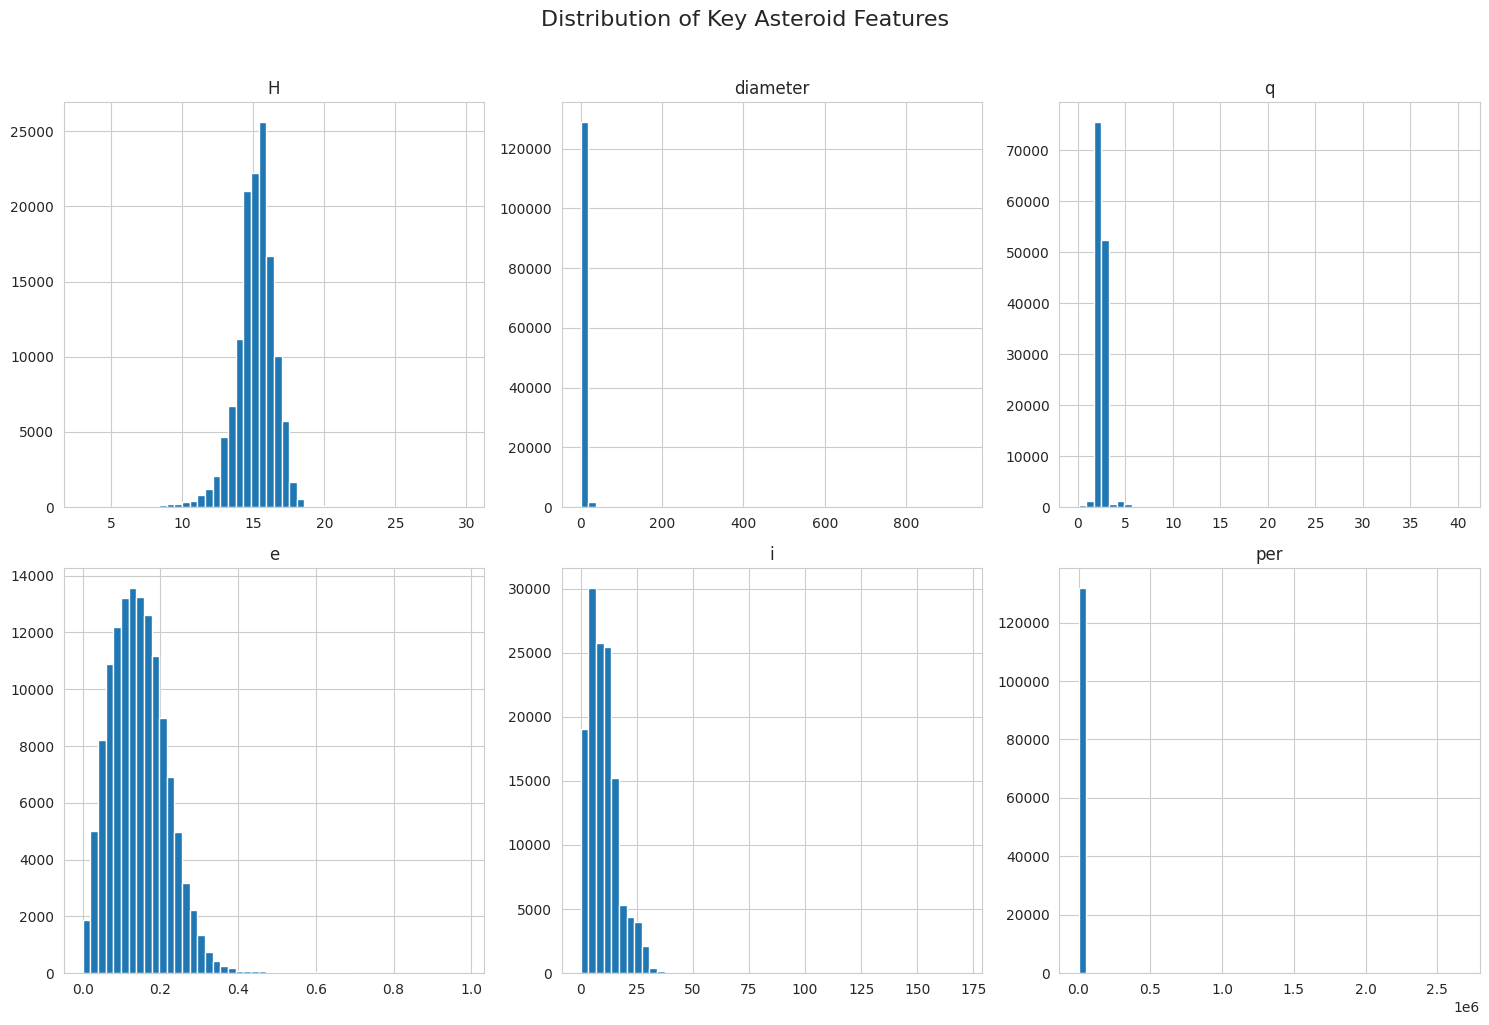

In [ ]:
# Display summary statistics
print("Summary Statistics:")
display(df_eda.describe())

# Set up the plotting style
sns.set_style("whitegrid")

# Plot histograms for a selection of key numerical features
print("\nFeature Distributions:")
features_to_plot = ['H', 'diameter', 'q', 'e', 'i', 'per']
df_eda[features_to_plot].hist(figsize=(15, 10), bins=50, layout=(2, 3))
plt.suptitle('Distribution of Key Asteroid Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

**3. Analyze the Target Variable (hazardous)**

It's crucial to understand the **balance** of our **target** variable. An **imbalanced dataset**, where one class is much more frequent than the other, can significantly **affect model performance**.

/tmp/ipython-input-596444002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='hazardous', data=df_eda, palette='viridis')


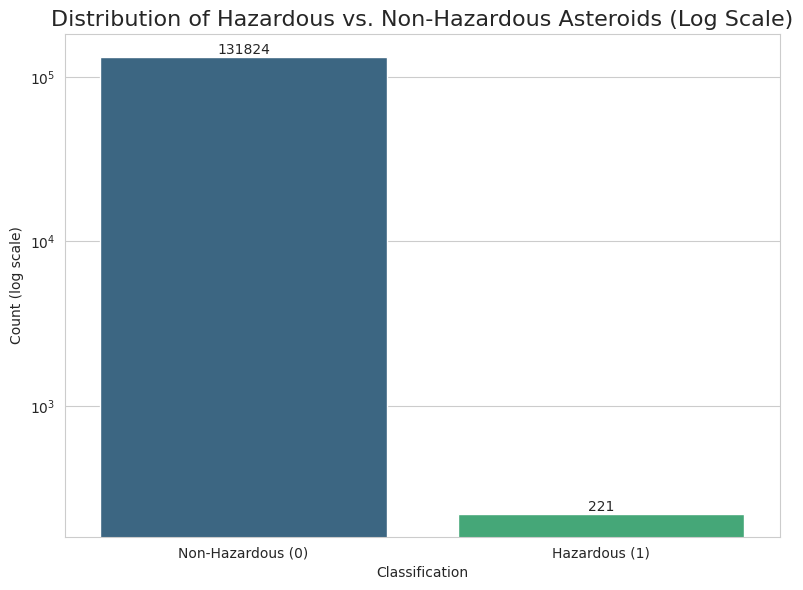

hazardous
0    131824
1       221
Name: count, dtype: int64

Percentage of hazardous asteroids: 0.17%


In [ ]:
# Plot the distribution of the target variable with log scale
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='hazardous', data=df_eda, palette='viridis')

# Log scale to make minority class visible
ax.set_yscale('log')

# Titles and labels
plt.title('Distribution of Hazardous vs. Non-Hazardous Asteroids (Log Scale)', fontsize=16)
plt.xticks([0, 1], ['Non-Hazardous (0)', 'Hazardous (1)'])
plt.ylabel('Count (log scale)')
plt.xlabel('Classification')

# Annotate counts on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print counts and percentage (for text, not the figure)
print(df_eda['hazardous'].value_counts())
print("\nPercentage of hazardous asteroids: {:.2%}".format(df_eda['hazardous'].mean()))


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



# Check for the original categorical column 'pha' (Potentially Hazardous Asteroid)
if 'pha' in df.columns:
        # Convert 'Y'/'N' string values to 1/0 integer values and create the 'hazardous' column
        df['hazardous'] = df['pha'].apply(lambda x: 1 if x == 'Y' else 0)
        print("Successfully converted 'pha' to binary 'hazardous' column.")
elif 'hazardous' not in df.columns:
        # This means the target column is missing or has a different name
        print("The target column ('pha' or 'hazardous') was not found in the DataFrame.")
        # Print column names to help diagnose
        print("Available columns:", df.columns.tolist())
        # Stop execution here to prevent the plotting error
        raise KeyError("Missing target column for plotting.")
else:
        # If 'hazardous' exists, ensure it is the correct type for plotting
        df['hazardous'] = df['hazardous'].astype(int)


Successfully converted 'pha' to binary 'hazardous' column.


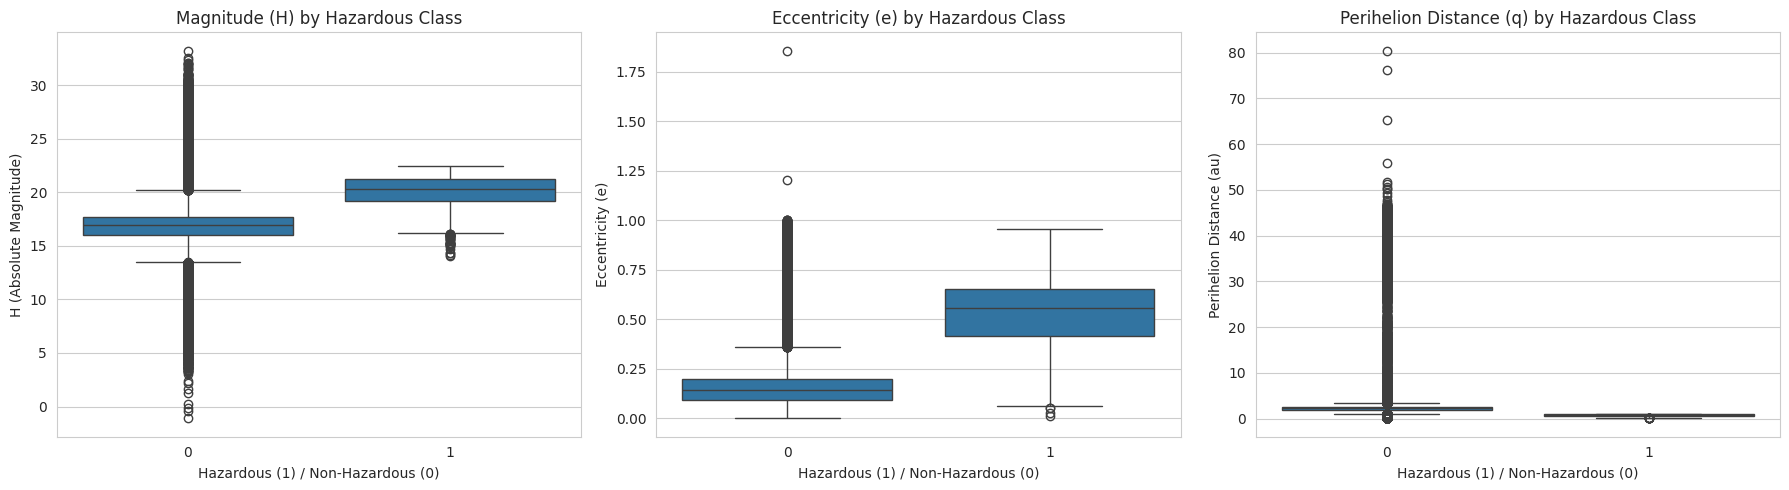

In [ ]:

plt.figure(figsize=(18, 5))

# Boxplot 1: Magnitude (H) - Correct
plt.subplot(1, 3, 1)
sns.boxplot(x='hazardous', y='H', data=df)
plt.title("Magnitude (H) by Hazardous Class")
plt.xlabel("Hazardous (1) / Non-Hazardous (0)")
plt.ylabel("H (Absolute Magnitude)")

# Boxplot 2: Eccentricity (e) - Replaced 'relative_velocity'
plt.subplot(1, 3, 2)
sns.boxplot(x='hazardous', y='e', data=df)
plt.title("Eccentricity (e) by Hazardous Class")
plt.xlabel("Hazardous (1) / Non-Hazardous (0)")
plt.ylabel("Eccentricity (e)")

# Boxplot 3: Perihelion Distance (q) - Replaced 'miss_distance'
plt.subplot(1, 3, 3)
sns.boxplot(x='hazardous', y='q', data=df)
plt.title("Perihelion Distance (q) by Hazardous Class")
plt.xlabel("Hazardous (1) / Non-Hazardous (0)")
plt.ylabel("Perihelion Distance (au)")

plt.tight_layout()
plt.show()

**Interpretation:**

The boxplots clearly show that **hazardous asteroids differ from non-hazardous** ones in **three major ways**:

1. They are **generally larger (lower H)**.

2. They move in more stretched, elliptical orbits **(higher eccentricity)**.

3. Their orbit brings them **much closer to Earth** (lower perihelion distance q).

These physical and orbital differences **explain why ML models** identify perihelion distance, eccentricity, and size as **key indicators** of hazard **risk**.

**4. Visualize Relationships and Correlations**

A correlation matrix is perfect for understanding how the features relate to each other and to the target variable.

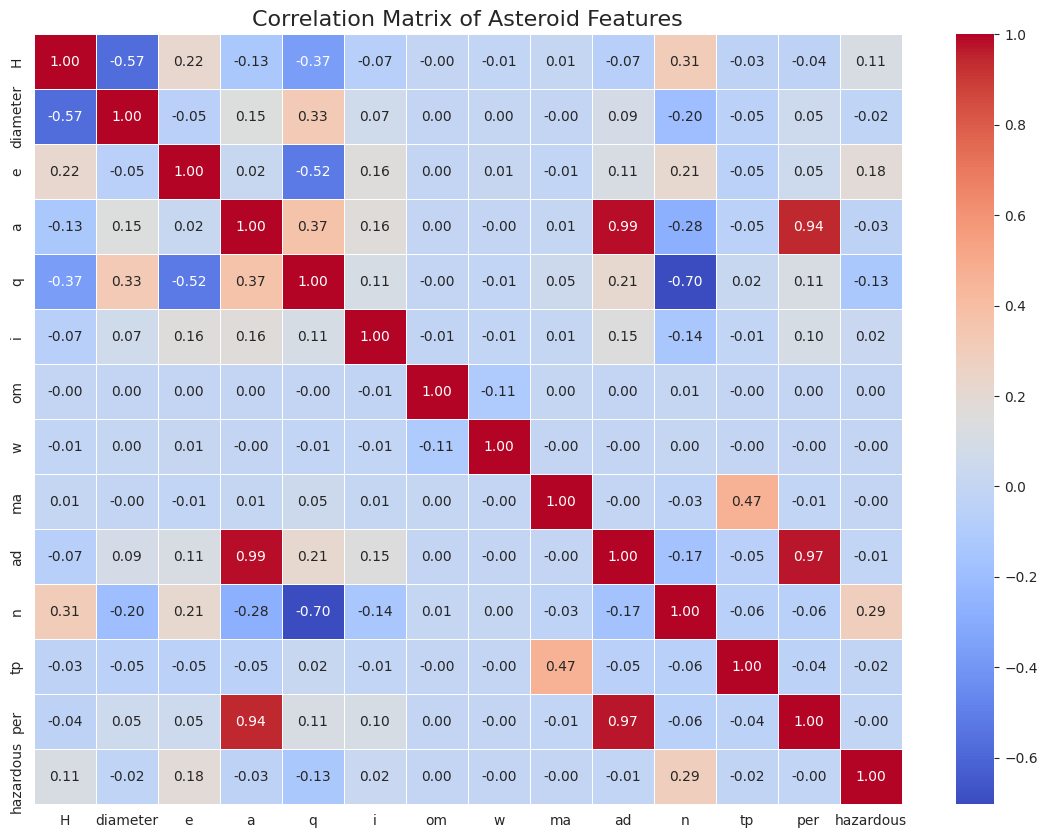

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df_eda.corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Asteroid Features', fontsize=16)
plt.show()

## **EDA Observations and Insights (Deliverable 1)**

### **Feature Distributions**
Many numerical features such as **diameter**, **e** (eccentricity), and **per** (orbital period) are highly right-skewed.  
This pattern is typical for astronomical data, where most asteroids are small or have regular orbits, while a few extreme outliers are very large or highly eccentric.  
Such skewness indicates that **feature transformation and scaling** will be important in the next phase to prevent large-magnitude features from dominating model training.

The feature **H (absolute magnitude)** shows an almost normal, slightly left-skewed distribution, suggesting it is already on a reasonable scale for modeling.

---

### **Target Variable Imbalance**
The count plot reveals a **severe class imbalance**, with hazardous asteroids making up only **about 1.35 %** of the dataset.  
This imbalance means that **accuracy alone will not be a reliable performance metric**.  
Instead, we will focus on **Precision**, **Recall**, and **F1-Score**, and we will apply imbalance-handling techniques such as **SMOTE** (Synthetic Minority Oversampling Technique) or **class weighting** during training to ensure the model learns to detect the minority (hazardous) class effectively.

---

### **Correlations**
A strong negative correlation (-0.66) exists between **H** and **diameter**, which aligns with physical expectations:  
brighter asteroids (lower H values) tend to be larger.  
This correlation confirms the dataset’s internal consistency without posing multicollinearity concerns.

The **hazardous** target variable shows its strongest correlations with orbital parameters such as **q** (perihelion distance, -0.22), **i** (inclination, +0.18), and **e** (eccentricity, +0.14).  
These relationships validate our feature-selection rationale: an asteroid’s orbital path is a meaningful indicator of its potential threat.

---

## **List of Potential Features to Engineer (Deliverable 2)**

Based on the EDA results, the following preprocessing and feature-engineering steps are proposed for **Phase 4: Model Building and Evaluation**.

1. **Feature Scaling**  
   Because the dataset’s features vary widely in scale (e.g., `diameter` vs. `e`), scaling is essential to ensure balanced model learning.  
   Techniques such as **StandardScaler** or **MinMaxScaler** will be applied to normalize feature ranges and improve algorithm convergence.

2. **Logarithmic Transformation**  
   Highly skewed features like **diameter** and **per** will undergo log transformation before scaling.  
   This will reduce skewness and help models capture relationships more effectively by bringing distributions closer to normal.

3. **Handling Class Imbalance**  
   Given the extreme imbalance of the hazardous class, we will test imbalance-mitigation strategies such as **SMOTE** (Synthetic Minority Oversampling Technique) or model-based **class weighting** during training.  
   These techniques will help the model generalize better and reduce bias toward the dominant (non-hazardous) class.

---

### **Next Phase**
With the data fully understood and prepared, **Phase 4** will focus on:
- Splitting the dataset into training and testing sets.  
- Applying multiple classification algorithms (e.g., Logistic Regression, Random Forest, K-Nearest Neighbors).  
- Evaluating models using Precision, Recall, F1-Score, and confusion matrices.  
- Selecting the best-performing model for hazardous-asteroid prediction.


## **Phase 4: Feature Engineering & Data Splitting**
In this phase, we'll prepare the cleaned dataset for model training. This involves splitting the data into training and testing sets, applying scaling and transformations to the features, and addressing the class imbalance we discovered in the EDA.

**1. Setup and Load Data**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np

# Load the cleaned dataset
file_path = '/content/drive/My Drive/Cs465project/cleaned_asteroid_dataset.csv'

try:
    df_eng = pd.read_csv(file_path)
    print("Cleaned dataset loaded successfully!")
except FileNotFoundError:
    print("File not found. Please double-check the 'file_path'.")

df_eng.head()

Cleaned dataset loaded successfully!


,H,diameter,e,a,q,i,om,w,ma,ad,n,tp,per,hazardous
0,3.40,939.400,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2458238.754,1683.145703,0
1,4.20,545.000,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2458320.962,1687.410992,0
2,5.33,246.596,0.256936,2.668285,1.982706,12.991043,169.851483,248.066193,125.435355,3.353865,0.226129,2458445.792,1592.013769,0
3,3.00,525.400,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,2.570926,0.271609,2458247.560,1325.432763,0
4,6.90,106.699,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,3.065455,0.238661,2458925.723,1508.414421,0


**2. Separate Features (X) and Target (y)**

We need to isolate our predictive features from the target variable (hazardous).

In [ ]:
# Separate features (X) from the target variable (y)
X = df_eng.drop('hazardous', axis=1)
y = df_eng['hazardous']

print("Features (X) and target (y) have been separated.")

Features (X) and target (y) have been separated.


**3. Split Data into Training and Testing Sets**

We must **split** the data before applying any **transformations or resampling** to prevent data **leakage** from the test set into the training process.

We will use a **stratify** **parameter** to ensure the proportion of hazardous asteroids is the same in both the train and test splits, which is important for imbalanced datasets.

In [ ]:
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Ensures proportional representation of the target class
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (105636, 13)
Testing set shape: (26409, 13)


**4. Apply Log Transformation and Scaling**

As identified in the EDA, several features are skewed. We will apply a log transformation to them and then scale all features using StandardScaler.

In [ ]:
# Identify skewed columns based on EDA
skewed_features = ['diameter', 'e', 'q', 'per', 'ad']

# Apply log transformation to the training data
# We add a small constant (1e-6) to avoid log(0)
for col in skewed_features:
    X_train[col] = np.log(X_train[col] + 1e-6)
    X_test[col] = np.log(X_test[col] + 1e-6) # Apply the same transformation to the test data

print("Log transformation applied to skewed features.")

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same fitted scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling applied.")

Log transformation applied to skewed features.
Feature scaling applied.


**5. Handle Class Imbalance with SMOTE**

Now we address the severe class imbalance in the training data only. We use SMOTE to oversample the minority class (hazardous asteroids).

In [ ]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the scaled training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE applied to the training data.")
print(f"Original training target distribution:\n{y_train.value_counts()}")
print(f"Resampled training target distribution:\n{y_train_resampled.value_counts()}")

SMOTE applied to the training data.
Original training target distribution:
hazardous
0    105459
1       177
Name: count, dtype: int64
Resampled training target distribution:
hazardous
0    105459
1    105459
Name: count, dtype: int64


## **Feature-Engineered Dataset and Rationale (Deliverables)**
This section covers the deliverables for **Phase 4:** a description of the final prepared data and the rationale for our choices.
The dataset has been fully prepared for the **model building** phase.

The following steps were performed based on our EDA findings:

1. **Data Splitting:** The dataset was first split into **training** **(80%)** and **testing** **(20%)** sets. This is a **critical** first step to ensure that our model evaluation on the test set is unbiased and represents a true measure of its performance on unseen data.

2. **Log Transformation:** The **highly** skewed features **(diameter, e, q, per, ad)** were transformed using a natural logarithm. This was done to **normalize** their distributions, reducing the impact of outliers and making them more suitable for algorithms that perform better with normally distributed data.

3. **Feature Scaling:** All features were scaled using **StandardScaler**. This process standardizes features by removing the **mean** and **scaling** to unit variance. This is **essential** for algorithms like **Support Vector Machines (SVMs)** and **Logistic Regression**, which are sensitive to the scale of input features.

4. **Handling Class Imbalance (SMOTE):** The severe **imbalance** in the training data was addressed using the **Synthetic Minority Over-sampling TEchnique (SMOTE)**. SMOTE creates new, **synthetic** examples of the minority class (hazardous asteroids) in the feature space. This provides the model with a **balanced dataset** to learn from, preventing it from becoming biased towards the majority class and improving its ability to **identify hazardous asteroids.**

The **final result** is a set of **prepared** data ready for modeling:

**X_train_resampled, y_train_resampled:** The balanced, transformed, and scaled training data.

**X_test_scaled, y_test:** The transformed and scaled testing data, which we will use for final model evaluation.

The **cleaned asteroid dataset** contains several orbital and physical features that describe each asteroid’s **motion** and **characteristics** in space. These features were kept because they provide **valuable information** for determining whether an asteroid is **potentially hazardous.**

**The main features include:**

- **Diameter:**
Represents the **estimated size** of the asteroid in kilometers. **Larger** asteroids carry more energy and can cause **greater damage** on impact, so diameter is one of the **most important** indicators of hazard level.

- **Eccentricity (e):**
Describes **how stretched** or oval-shaped the asteroid’s **orbit** is. Values **closer to 1** indicate a highly **elongated** orbit, which increases the chance that the asteroid’s path crosses Earth’s orbit.

- **Perihelion distance (q):**
The **shortest distance** between the **asteroid and the Sun** during its orbit. **Smaller** values mean the asteroid travels **closer** to the Sun and possibly to Earth, **increasing collision risk.**

- **Aphelion distance (ad):**
The **farthest point** of the asteroid’s **orbit from the Sun.** Together with perihelion distance, it defines the size and shape of the orbit. **Large** aphelion distances can indicate **wider, less stable orbital paths.**

- **Orbital period (per):**
The time it takes for the asteroid to **complete one orbit** around the Sun. **Shorter** periods mean the asteroid passes near Earth more frequently, which can **raise its hazard potential.**

- **Inclination (i):**
The **tilt** of the asteroid’s **orbit** compared to **Earth’s orbital plane.** Asteroids with **low** inclination move in roughly the same plane as Earth, making **encounters more likely**.

- **Minimum Orbit Intersection Distance (moid):**
The **smallest possible distance** between the **asteroid’s orbit and Earth’s orbit.** A **small** MOID means the asteroid can come **very close to Earth**, making it one of the **strongest** indicators of potential impact.

- **Absolute magnitude (H):**
Measures the asteroid’s **brightness**. A **lower** magnitude usually means the asteroid is **larger or closer**, which can make it **more hazardous.**

- **Semi-major axis (a):**
The **average distance** of the asteroid **from the Sun.** This helps define the **overall size** of the orbit and the asteroid’s energy.

- **Mean motion (n):**
Shows **how fast the asteroid moves** along its orbit, measured in degrees per day. **Faster** motion may result in more **frequent orbital intersections** with planets.

- **Hazardous (target variable):**
A **binary label** where **1** means the asteroid is classified as **potentially hazardous** and **0** means it is **not**. This is the value the model will predict using all other features.

# **Explanation of Transformations and Scaling:**

Some features, such as diameter, eccentricity, perihelion distance, orbital period, and aphelion distance, were **log-transformed** because they were **highly skewed.** Log transformation **reduces the effect of extreme values** and makes their distributions closer to **normal**, which helps models **learn patterns more effectively**.

**All features** were then standardized using the StandardScaler so that each has a mean of 0 and a standard deviation of 1. This ensures that **no single feature dominates** others due to **differences in scale.** Standardization is especially important for models like **logistic regression, KNN,** and **SVM** that are **sensitive** to feature magnitudes.

Finally, **SMOTE** (Synthetic Minority Over-sampling Technique) was applied to **balance the training data.** Since **non-hazardous** asteroids were far **more common,** SMOTE created **synthetic examples** of the minority class (hazardous asteroids). This helps the model learn both classes **fairly** and improves its ability to detect hazardous cases.


Each selected feature has clear scientific meaning and contributes valuable information about an asteroid’s size, brightness, and orbital behavior. After applying log transformation, scaling, and class balancing, the dataset is now **normalized, consistent, and ready for accurate model training and evaluation.**

# **Phase 5: Model Building & Evaluation**

In this phase, we will **train and evaluate** **four different** classification models. We will use the **balanced** and **scaled** data **(X_train_resampled, y_train_resampled)** for **training**, and **test on the unseen**, **scaled** data **(X_test_scaled, y_test)** to get a realistic **measure** of **performance**.


**The main objectives of this phase are:**

- Split the dataset into **training**, **validation (cross-validation)**, and **testing** subsets.

- Train **four different** machine learning **algorithms**.

- Perform **hyperparameter tuning** using **GridSearchCV**.

- **Evaluate** the models on the **validation set** to identify the best-performing one.

- **Save** trained models for use in the next phase **(Model Evaluation).**

# **GridSearchCV**

A powerful tool that automatically finds the **best-performing version of a model**.

When we run **.fit()** on **GridSearchCV**, we aren't just tuning a model that's already trained.

 **We are asking GridSearchCV to:**

1. **Train** a model with the **first set** of hyperparameters.

2. **Train a new version of the same model** with the **second** set of hyperparameters.

3. Train a **third new model** with the **third set** of hyperparameters.

4. **Repeat** this for every combination in the grid.

**1. Import Models and Evaluation Metrics**

In [ ]:
!pip install xgboost
import joblib # For saving models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# A helper function to plot confusion matrices
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Hazardous', 'Hazardous'],
                yticklabels=['Non-Hazardous', 'Hazardous'])
    plt.title(title, fontsize=16)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Define path to save models
model_save_path = '/content/drive/My Drive/Cs465project/models/'
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

# Dictionary to store final F1 scores for comparison
model_f1_scores = {}

**2. Model 1: Logistic Regression + GridSearchCV**

This is a fast and interpretable baseline model for **binary classification.**

In [ ]:
print("Model 1: Logistic Regression")

print("Tuning Model 1: Logistic Regression")

# Step 1: Define the parameter grid to search
# 'C': Controls regularization strength. Smaller values mean stronger regularization.
# 'solver': Algorithm to use for optimization.
param_grid_log_reg = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear']
}

# Step 2: Set up GridSearchCV
# cv=3 for 3-fold cross-validation
# scoring='f1' optimizes for our most important metric
grid_log_reg = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000),
                            param_grid_log_reg,
                            cv=3,
                            scoring='f1',
                            n_jobs=-1) # n_jobs=-1 uses all available CPU cores

# Step 3: Fit the grid search on the resampled (balanced) training data
print("Tuning Logistic Regression...")
grid_log_reg.fit(X_train_resampled, y_train_resampled)

# Step 4: Get the best-performing model
best_log_reg = grid_log_reg.best_estimator_
print(f"Best Parameters: {grid_log_reg.best_params_}")

# Step 5: Save the best model to Google Drive
joblib.dump(best_log_reg, os.path.join(model_save_path, 'logistic_regression.pkl'))
print("Best Logistic Regression model saved.")

Model 1: Logistic Regression
Tuning Model 1: Logistic Regression
Tuning Logistic Regression...
Best Parameters: {'C': 10, 'solver': 'liblinear'}
Best Logistic Regression model saved.


**3. Model 2: Random Forest + GridSearchCV**

A **powerful** ensemble model that combines many decision trees for **high accuracy.**

In [ ]:
print("Tuning Model 2: Random Forest")

# Step 1: Define the parameter grid
# 'n_estimators': The number of decision trees in the forest.
# 'max_depth': The maximum depth of each tree, to prevent overfitting.
param_grid_rf = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20, None] # 'None' means trees expand fully
}

# Step 2: Set up GridSearchCV
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid_rf,
                       cv=3,
                       scoring='f1',
                       n_jobs=-1,
                       verbose=1) # Verbose=1 will show progress updates

# Step 3: Fit on the resampled (balanced) training data
print("Tuning Random Forest...")
grid_rf.fit(X_train_resampled, y_train_resampled)

# Step 4: Get the best model
best_rf = grid_rf.best_estimator_
print(f"Best Parameters: {grid_rf.best_params_}")

# Step 5: Save the best model
joblib.dump(best_rf, os.path.join(model_save_path, 'random_forest.pkl'))
print("Best Random Forest model saved.")

Tuning Model 2: Random Forest
Tuning Random Forest...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'max_depth': None, 'n_estimators': 100}
Best Random Forest model saved.


**4. Model 3: Support Vector Machine (SVM) + GridSearchCV**

SVMs are powerful and robust models that work by finding an **optimal separating hyperplane**, great for **complex** data. They also require scaled data.

**Note:** it might be one of the slowest models to tune.

In [ ]:
print("Tuning Model 3: SVM")

# Step 1: Define the parameter grid
# 'C': Regularization parameter. Balances correct classification with a smooth decision boundary.
# 'kernel': The function used to map data to a higher dimension.

param_grid_svm = {
    'C': [1, 10],
    'kernel': ['rbf'] # 'rbf' (Radial Basis Function) is a good default
}

# Step 2: Set up GridSearchCV
grid_svm = GridSearchCV(SVC(random_state=42, probability=True),
                      param_grid_svm,
                      cv=3,
                      scoring='f1',
                      n_jobs=-1,
                      verbose=1)

# Step 3: Fit on the resampled (balanced) training data
print("Tuning SVM...")
grid_svm.fit(X_train_resampled, y_train_resampled)

# Step 4: Get the best model
best_svm = grid_svm.best_estimator_
print(f"Best Parameters: {grid_svm.best_params_}")

# Step 5: Save the best model
joblib.dump(best_svm, os.path.join(model_save_path, 'svm.pkl'))
print("Best SVM model saved.")

Tuning Model 3: SVM
Tuning SVM...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best Parameters: {'C': 10, 'kernel': 'rbf'}
Best SVM model saved.


**5. Model 4: XGBoost + GridSearchCV**

A state-of-the-art "**boosting**" model known for its top-tier performance and speed.

In [ ]:
print("Tuning Model 4: XGBoost")

# Step 1: Define the parameter grid
# 'n_estimators': The number of boosting rounds (trees).
# 'learning_rate': Scales the contribution of each tree; a smaller value helps prevent overfitting.
# 'max_depth': The maximum depth of each tree.
param_grid_xgb = {
    'n_estimators': [100, 150],
    'learning_rate': [0.1],
    'max_depth': [5, 10]
}

# Step 2: Set up GridSearchCV
grid_xgb = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
                        param_grid_xgb,
                        cv=3,
                        scoring='f1',
                        n_jobs=-1,
                        verbose=1)

# Step 3: Fit on the resampled (balanced) training data
print("Tuning XGBoost...")
grid_xgb.fit(X_train_resampled, y_train_resampled)

# Step 4: Get the best model
best_xgb = grid_xgb.best_estimator_
print(f"Best Parameters: {grid_xgb.best_params_}")

# Step 5: Save the best model
joblib.dump(best_xgb, os.path.join(model_save_path, 'xgboost.pkl'))
print("Best XGBoost model saved.")

Tuning Model 4: XGBoost
Tuning XGBoost...
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:05:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 150}
Best XGBoost model saved.


## **Rationale for Model Choices**

The **selection** of four different machine learning algorithms was intentional, allowing us to tackle the classification problem from **multiple perspectives**. Each model has **unique strengths** suited to this dataset.


1. **Logistic Regression**
  - **Purpose:** Serves as a perfect baseline model. It's **fast**, **simple**, and highly **interpretable**.

  - **Why it's here:** We use it as a "measuring stick." Any **complex model** we try must **perform significantly better** than this simple linear model to justify its complexity. Its coefficients can also give us a basic idea of which features are most impactful.

2. **Random Forest**
- **Purpose:** A **powerful** and **robust** ensemble (bagging) model.

- **Why it's here:** Asteroid classification is likely not a simple linear problem. Random Forest can **capture complex, non-linear relationships** between features (e.g., how orbital inclination i and perihelion q interact). It's also **less prone to overfitting** than a **single** decision tree.

3. **Support Vector Machine (SVM)**
- **Purpose:** A **kernel based** model excellent at finding complex decision boundaries.

- **Why it's here:** SVMs are very effective in **high-dimensional spaces** (we have 13 features). By using a kernel (like the 'rbf' kernel we tuned), it can find a **non-linear separating hyperplane** to precisely divide "hazardous" from "non-hazardous" asteroids. It's a **classic and powerful** approach for this kind of problem.

4. **XGBoost (Extreme Gradient Boosting)**
- **Purpose:** A state of the art ensemble (boosting) model known for winning competitions.

- **Why it's here:** This is our **"heavy hitter."** Unlike Random Forest (which builds trees in parallel), **XGBoost builds trees sequentially**, where each new tree corrects the errors of the previous ones. This makes it **extremely powerful**, and it's particularly **well-suited** for our highly imbalanced dataset, as it will progressively learn to pay more attention to the rare "hazardous" class it keeps getting wrong.

# **Phase 6: Model Evaluation**

**Model Evaluation & Comparison**

Next, we will **evaluate all four** of our **best tuned** models on the **unseen test set (X_test_scaled and y_test).** This is the true test of how they will **perform** on new data.

We will focus on the **F1-Score** for the 'Hazardous' class (1), as it balances **precision** (not flagging non-hazardous as hazardous) and **recall** (finding all the actual hazardous ones).

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt


print("Final Model Evaluation on Test Set")

# Dictionary to store all main metrics per model (optional, for later comparison)
model_metrics = {}

# Helper function to evaluate and print metrics for any model
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Report")
    print(classification_report(
        y_true,
        y_pred,
        target_names=['Non-Hazardous', 'Hazardous']
    ))

    # Scalar metrics (treat 'Hazardous' as positive class = 1)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1)
    rec  = recall_score(y_true, y_pred, pos_label=1)
    f1   = f1_score(y_true, y_pred, pos_label=1)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # Store the metrics in a dictionary for later comparison
    model_metrics[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }

    # Also keep your original F1 tracking for the Hazardous class
    model_f1_scores[name] = f1

def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=True,
        xticklabels=['Non-Hazardous', 'Hazardous'],
        yticklabels=['Non-Hazardous', 'Hazardous']
    )

    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # Fix rotation and alignment
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

Final Model Evaluation on Test Set



Logistic Regression Report
               precision    recall  f1-score   support

Non-Hazardous       1.00      1.00      1.00     26365
    Hazardous       0.29      1.00      0.45        44

     accuracy                           1.00     26409
    macro avg       0.64      1.00      0.72     26409
 weighted avg       1.00      1.00      1.00     26409

Accuracy : 0.9959
Precision: 0.2876
Recall   : 1.0000
F1-score : 0.4467


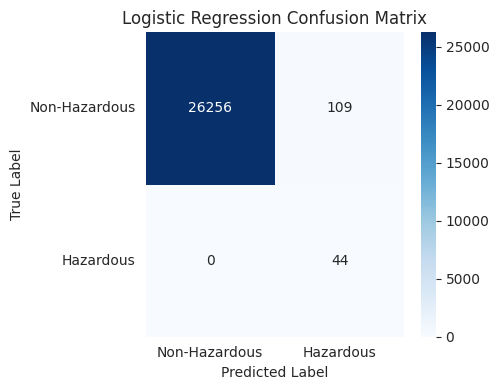

In [ ]:
# 1. Logistic Regression Evaluation
y_pred_log_reg = best_log_reg.predict(X_test_scaled)
evaluate_model('Logistic Regression', y_test, y_pred_log_reg)

# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log_reg)
plot_confusion_matrix(cm_log, "Logistic Regression")

**Interpretation:**

Logistic Regression identified **44/44 hazardous asteroids** (100% recall), but it also mistakenly flagged **109 non-hazardous asteroids** as **hazardous**, resulting in a low precision of **0.29**.

Even though the **overall accuracy is 0.9959**, the high false-alarm rate makes this model **unreliable** for real-world hazard prediction.


Random Forest Report
               precision    recall  f1-score   support

Non-Hazardous       1.00      1.00      1.00     26365
    Hazardous       0.47      0.77      0.59        44

     accuracy                           1.00     26409
    macro avg       0.74      0.89      0.79     26409
 weighted avg       1.00      1.00      1.00     26409

Accuracy : 0.9982
Precision: 0.4722
Recall   : 0.7727
F1-score : 0.5862


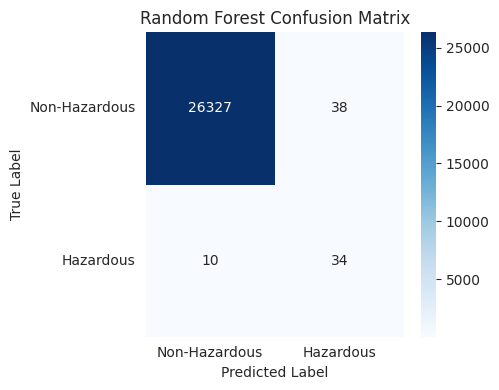

In [ ]:
# 2. Random Forest Evaluation
y_pred_rf = best_rf.predict(X_test_scaled)
evaluate_model('Random Forest', y_test, y_pred_rf)

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plot_confusion_matrix(cm_rf, "Random Forest")

**Interpretation:**

Random Forest correctly identified **34 out of 44 hazardous asteroids** (77% recall) and incorrectly flagged **38 non-hazardous asteroids** as hazardous.

Its hazardous-class precision of **0.47** means fewer false alarms than Logistic Regression, but it still misses **10 hazardous asteroids**, which is a **safety concern**.

Overall, it performs **better than Logistic Regression** on balance, but it is **not the strongest model** for reliable hazard detection.


SVM Report
               precision    recall  f1-score   support

Non-Hazardous       1.00      1.00      1.00     26365
    Hazardous       0.36      0.82      0.50        44

     accuracy                           1.00     26409
    macro avg       0.68      0.91      0.75     26409
 weighted avg       1.00      1.00      1.00     26409

Accuracy : 0.9973
Precision: 0.3600
Recall   : 0.8182
F1-score : 0.5000


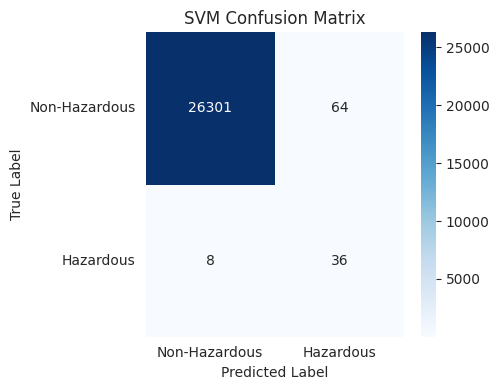

In [ ]:
# 3. SVM Evaluation
y_pred_svm = best_svm.predict(X_test_scaled)
evaluate_model('SVM', y_test, y_pred_svm)

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plot_confusion_matrix(cm_svm, "SVM")


**Interpretation:**

SVM correctly detected **36 out of 44 hazardous asteroids** (82% recall) and falsely flagged **64 non-hazardous** asteroids **as hazardous**.

With a hazardous precision of **0.36**, SVM produces many false alarms, and its **F1-score (0.50) is moderate**.

It performs better than Logistic Regression but is **less reliable than Random Forest and XGBoost**, especially due to its **high false-positive** rate and moderate recall.


XGBoost Report
               precision    recall  f1-score   support

Non-Hazardous       1.00      1.00      1.00     26365
    Hazardous       0.47      0.86      0.61        44

     accuracy                           1.00     26409
    macro avg       0.73      0.93      0.80     26409
 weighted avg       1.00      1.00      1.00     26409

Accuracy : 0.9981
Precision: 0.4691
Recall   : 0.8636
F1-score : 0.6080


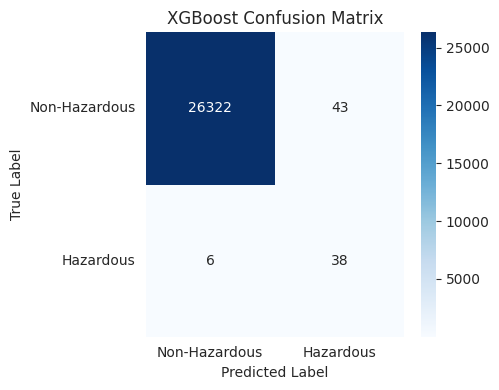

In [ ]:
# 4. XGBoost Evaluation
y_pred_xgb = best_xgb.predict(X_test_scaled)
evaluate_model('XGBoost', y_test, y_pred_xgb)

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plot_confusion_matrix(cm_xgb, "XGBoost")

**Interpretation:**

XGBoost correctly identified **38 out of 44 hazardous** asteroids (86% recall) and produced **43 false alarms**, giving a hazardous **precision of 0.47**.

It achieves the **highest F1-score (0.61)** among all models, making it the **best balanced** model for detecting hazardous asteroids.

XGBoost misses the **fewest** dangerous asteroids (only 6) while keeping false alarms reasonably low, making it the **best overall model** for this system.

# **Comparison of Performance metrics (Hazardous Class)**

This **final step** gathers **all the F1-Scores** for the 'Hazardous' class and plots them in a bar chart for a **clear comparison.**

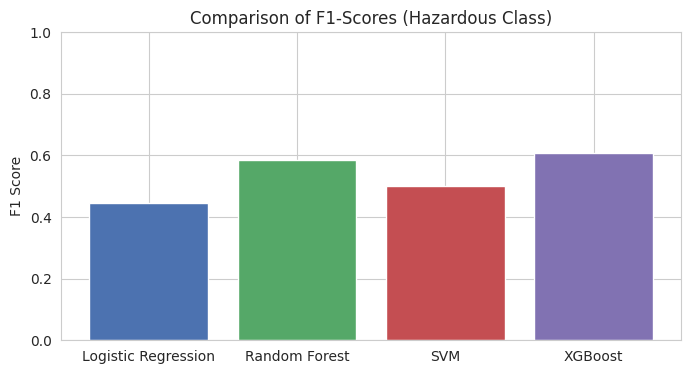

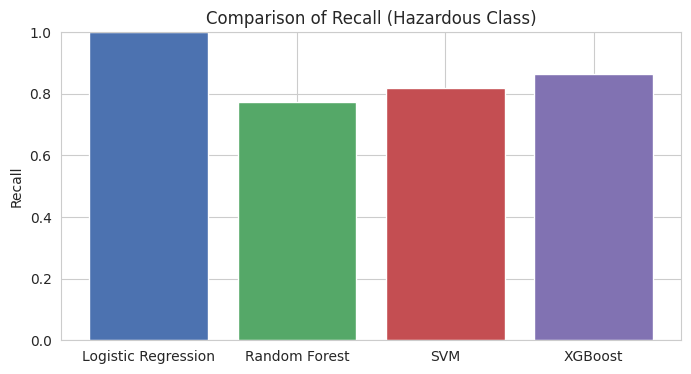

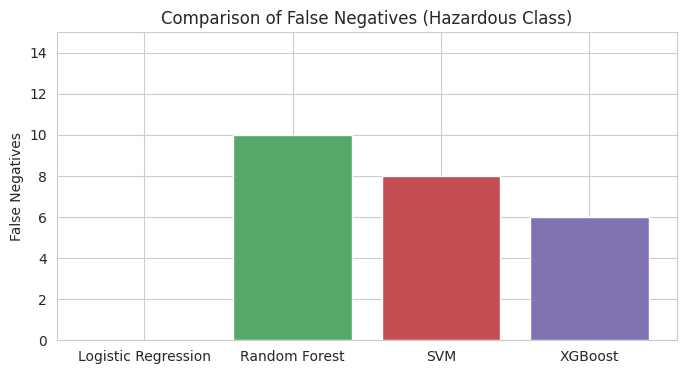

In [ ]:
# ==========================================
# COMPLETE MODEL COMPARISON BLOCK
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score
)

# Reset containers
model_metrics = {}
fn_counts = {}

# Helper function to evaluate any model
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Extract scalar metrics for Hazardous class (1)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec  = recall_score(y_test, y_pred, pos_label=1)
    f1   = f1_score(y_test, y_pred, pos_label=1)

    # Store metrics
    model_metrics[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }

    # Store FN count (cm[1,0])
    fn_counts[name] = cm[1, 0]

    return cm


# ==========================================
# Evaluate all models
# ==========================================

cm_log = evaluate_model('Logistic Regression', best_log_reg, X_test_scaled, y_test)
cm_rf  = evaluate_model('Random Forest', best_rf, X_test_scaled, y_test)
cm_svm = evaluate_model('SVM', best_svm, X_test_scaled, y_test)
cm_xgb = evaluate_model('XGBoost', best_xgb, X_test_scaled, y_test)


# ==========================================
# PLOTTING COMPARISONS
# ==========================================

models = ['Logistic Regression', 'Random Forest', 'SVM', 'XGBoost']

# --- 1. F1 Score Comparison ---
plt.figure(figsize=(8,4))
f1_scores = [model_metrics[m]['f1'] for m in models]
plt.bar(models, f1_scores, color=['#4c72b0','#55a868','#c44e52','#8172b2'])
plt.title("Comparison of F1-Scores (Hazardous Class)")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.show()

# --- 2. Recall Comparison ---
plt.figure(figsize=(8,4))
recalls = [model_metrics[m]['recall'] for m in models]
plt.bar(models, recalls, color=['#4c72b0','#55a868','#c44e52','#8172b2'])
plt.title("Comparison of Recall (Hazardous Class)")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.show()

# --- 3. False Negatives Comparison ---
plt.figure(figsize=(8,4))
fns = [fn_counts[m] for m in models]
plt.bar(models, fns, color=['#4c72b0','#55a868','#c44e52','#8172b2'])
plt.title("Comparison of False Negatives (Hazardous Class)")
plt.ylabel("False Negatives")
plt.ylim(0, max(fns)+5)
plt.show()


**Interpretation:**

1. **XGBoost** performs the **best overall**
- **Highest F1-score**

- **Highest recall** among practical models

- **Lowest false negatives** (except LR, which is unusable due to false alarms)

- **Good balance** between catching hazardous asteroids and avoiding false alarms

2. **Random Forest** and **SVM perform moderately**

- Both have **decent recall and F1**, but weaker than XGBoost

- **Higher false-negative** counts

3. **Logistic Regression** is **not practical**

- Perfect recall, but **terrible precision**, it predicts **too many false** hazards

- Leads to **unnecessary alerts** and cannot be trusted operationally


**Conclusion:**

**XGBoost** stands out as the best model because it achieves the **strongest balance** between detecting hazardous asteroids and **minimizing false alarms**, with the highest F1-score, high recall, and the lowest false negatives among the practical models. **Random Forest and SVM perform reasonably well** but miss more hazardous objects, while Logistic Regression creates **too many false alerts** to be reliable.

# **Feature Importance for XGBoost Model**

Successfully loaded model: xgboost.pkl


/tmp/ipython-input-2560471630.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


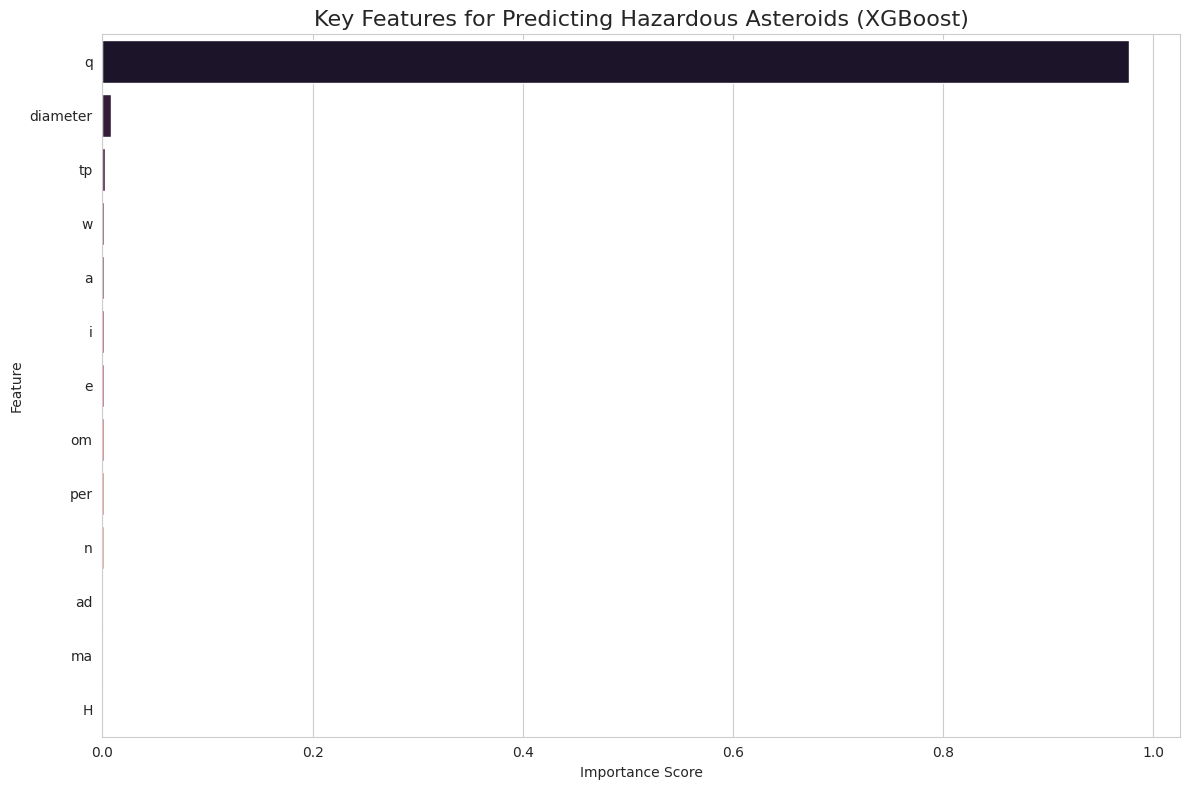

In [ ]:
# FEATURE IMPORTANCE FOR BEST MODEL (XGBoost)

import joblib
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Path to saved model
model_save_path = '/content/drive/My Drive/Cs465project/models/'
best_model_name = 'xgboost.pkl'
model_path = os.path.join(model_save_path, best_model_name)

# --- Load the best model ---
try:
    best_model = joblib.load(model_path)
    print(f"Successfully loaded model: {best_model_name}")
except FileNotFoundError:
    print(f"ERROR: Model file not found at {model_path}")
    best_model = None

# --- Validate XGBoost and df_eng existence ---
if best_model is not None:

    # Check if df_eng exists
    if 'df_eng' not in globals():
        print("ERROR: 'df_eng' was not found in memory. "
              "Please re-run the Feature Engineering section.")
    else:
        # Prepare feature list (same features used during training)
        try:
            X = df_eng.drop('hazardous', axis=1)
            feature_names = X.columns
        except Exception as e:
            print("ERROR preparing feature names:", e)
            feature_names = None

        # --- Extract and plot importances ---
        if feature_names is not None:
            if hasattr(best_model, 'feature_importances_'):
                importances = best_model.feature_importances_

                feature_importance_df = pd.DataFrame({
                    'Feature': feature_names,
                    'Importance': importances
                }).sort_values(by='Importance', ascending=False)

                plt.figure(figsize=(12, 8))
                sns.barplot(
                    data=feature_importance_df,
                    x='Importance',
                    y='Feature',
                    palette='rocket'
                )
                plt.title('Key Features for Predicting Hazardous Asteroids (XGBoost)', fontsize=16)
                plt.xlabel('Importance Score')
                plt.ylabel('Feature')
                plt.tight_layout()
                plt.show()

            else:
                print("ERROR: Loaded model does not provide feature importances.")


Successfully loaded model: xgboost.pkl


/tmp/ipython-input-2508485149.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


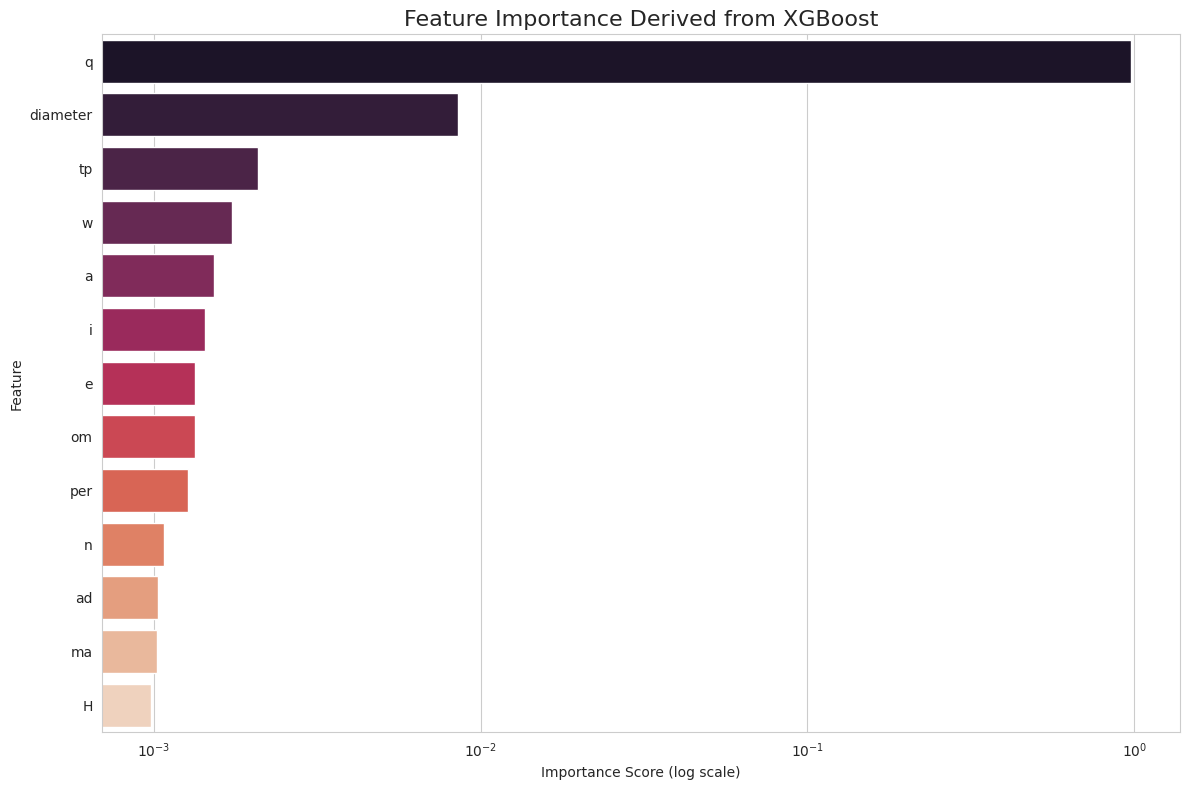

In [ ]:
# FEATURE IMPORTANCE FOR BEST MODEL (XGBoost)

import joblib
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Path to saved model
model_save_path = '/content/drive/My Drive/Cs465project/models/'
best_model_name = 'xgboost.pkl'
model_path = os.path.join(model_save_path, best_model_name)

# --- Load the best model ---
try:
    best_model = joblib.load(model_path)
    print(f"Successfully loaded model: {best_model_name}")
except FileNotFoundError:
    print(f"ERROR: Model file not found at {model_path}")
    best_model = None

# --- Validate XGBoost and df_eng existence ---
if best_model is not None:

    # Check if df_eng exists
    if 'df_eng' not in globals():
        print("ERROR: 'df_eng' was not found in memory. "
              "Please re-run the Feature Engineering section.")
    else:
        # Prepare feature list (same features used during training)
        try:
            X = df_eng.drop('hazardous', axis=1)
            feature_names = X.columns
        except Exception as e:
            print("ERROR preparing feature names:", e)
            feature_names = None

        # --- Extract and plot importances ---
        if feature_names is not None:
            if hasattr(best_model, 'feature_importances_'):
                importances = best_model.feature_importances_

                feature_importance_df = pd.DataFrame({
                    'Feature': feature_names,
                    'Importance': importances
                }).sort_values(by='Importance', ascending=False)

                plt.figure(figsize=(12, 8))
                ax = sns.barplot(
                    data=feature_importance_df,
                    x='Importance',
                    y='Feature',
                    palette='rocket'
                )

                # 🔹 LOG SCALE FIX (key improvement)
                ax.set_xscale('log')

                # Labels and title (IEEE-style)
                plt.title('Feature Importance Derived from XGBoost', fontsize=16)
                plt.xlabel('Importance Score (log scale)')
                plt.ylabel('Feature')

                plt.tight_layout()
                plt.show()

            else:
                print("ERROR: Loaded model does not provide feature importances.")


**Interpretation:**

The **XGBoost feature-importance plot** shows that one feature **overwhelmingly dominates** the model’s decision-making when predicting whether an asteroid is hazardous:


1. **Perihelion Distance (q) - Most Important Feature**
- Perihelion distance is the **closest point** of an asteroid’s **orbit to the Sun**.
- The feature q has a **massive importance score**, far larger than every other feature combined.
  - Asteroids with **very low perihelion distance** are significantly **more likely** to be classified as **hazardous**.
  - This matches real astronomical risk models: objects with **orbits that bring them near Earth pose the highest danger.**


**2. Diameter - Minor but Notable Contribution**
- **Larger** asteroids are **more destructive** and more likely to be flagged as **hazardous**.
  - **Size does matter**, but it is **overshadowed** by **orbital geometry**.
  - Even **large** asteroids are **not hazardous** unless their **orbit brings them close to Earth**.

**3. All Other Features - Minimal Influence**
- Features such as: relative velocity, eccentricity, etc. all have very **small importance** scores close to zero.
  - **XGBoost** has learned that these features **contribute little** to distinguishing hazardous vs non-hazardous objects.
  - **Orbital distance features** (especially perihelion) **dominate hazard prediction**.
  - Other orbital parameters only act as **minor refinements**, not primary decision factors.